# RAG RGPD — avec BERT et PyTorch


In [5]:
# Scraping et parsing
from bs4 import BeautifulSoup
import requests
import json
import re

# Chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter

# BERT
from transformers import BertTokenizer, BertModel

# PyTorch / NumPy / viz
import torch
import numpy as np
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

In [6]:
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")

Device utilisé : cpu


## 1. Chargement et parsing du RGPD

In [16]:
with open("L_2016119FR.01000101.html", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")



def clean_text(element):
    if element is None:
        return ""
    return element.get_text(" ", strip=True)


resultat = []

# On prend uniquement les vrais chapitres : cpt_I, cpt_II, cpt_III...
chapitres = soup.find_all("div", id=re.compile(r"^cpt_[IVXLCDM]+$"))

for chapitre in chapitres:

    chapitre_nom = clean_text(chapitre.find("p", class_="oj-ti-section-1"))
    titre_chapitre = clean_text(chapitre.find("p", class_="oj-ti-section-2"))

    # Sécurité : on ignore les blocs qui ne sont pas de vrais chapitres
    if not chapitre_nom.startswith("CHAPITRE"):
        continue

    chapitre_data = {
        "chapitre": chapitre_nom,
        "titre_chapitre": titre_chapitre,
        "contenu": []
    }

    # On récupère seulement les vrais articles : art_1, art_2, art_3...
    articles = chapitre.find_all("div", id=re.compile(r"^art_\d+$"))

    articles_deja_vus = set()

    for article in articles:

        article_id = article.get("id")

        # Évite les doublons
        if article_id in articles_deja_vus:
            continue
        articles_deja_vus.add(article_id)

        numero_article = clean_text(article.find("p", class_="oj-ti-art"))
        titre_article = clean_text(article.find("p", class_="oj-sti-art"))

        # Sécurité : on ignore les faux articles vides
        if not numero_article.startswith("Article"):
            continue

        paragraphes = article.find_all("p", class_="oj-normal")

        contenu_article = "\n".join(
            clean_text(p)
            for p in paragraphes
            if clean_text(p)
        )

        chapitre_data["contenu"].append({
            "article": numero_article,
            "titre_article": titre_article,
            "contenu_article": contenu_article
        })

    resultat.append(chapitre_data)


print(json.dumps(resultat, ensure_ascii=False, indent=4))

with open("rgpd_structure.json", "w", encoding="utf-8") as f:
    json.dump(resultat, f, ensure_ascii=False, indent=4)

[
    {
        "chapitre": "CHAPITRE I",
        "titre_chapitre": "Dispositions générales",
        "contenu": [
            {
                "article": "Article premier",
                "titre_article": "Objet et objectifs",
                "contenu_article": "1.   Le présent règlement établit des règles relatives à la protection des personnes physiques à l'égard du traitement des données à caractère personnel et des règles relatives à la libre circulation de ces données.\n2.   Le présent règlement protège les libertés et droits fondamentaux des personnes physiques, et en particulier leur droit à la protection des données à caractère personnel.\n3.   La libre circulation des données à caractère personnel au sein de l'Union n'est ni limitée ni interdite pour des motifs liés à la protection des personnes physiques à l'égard du traitement des données à caractère personnel."
            },
            {
                "article": "Article 2",
                "titre_article": "Champ d'

## 2. Lecture et structuration du JSON par chapitre

In [17]:
def read_and_split_json_by_chapter(filename):
    with open(filename, "r", encoding="utf-8") as file:
        data = json.load(file)

    documents = []
    for chapitre in data:
        chapitre_num = chapitre.get("chapitre", "")
        titre_chapitre = chapitre.get("titre_chapitre", "")
        articles = chapitre.get("contenu", [])

        texte_chapitre = f"{chapitre_num}\n{titre_chapitre}\n\n"

        for article in articles:
            numero_article = article.get("article", "")
            titre_article = article.get("titre_article", "")
            contenu_article = article.get("contenu_article", "")
            texte_chapitre += f"{numero_article}\n{titre_article}\n{contenu_article}\n\n"

        documents.append({
            "chapitre": chapitre_num,
            "titre_chapitre": titre_chapitre,
            "text": texte_chapitre.strip()
        })

    return documents

documents = read_and_split_json_by_chapter("rgpd_structure.json")
print(documents[0]["text"][:500])

CHAPITRE I
Dispositions générales

Article premier
Objet et objectifs
1.   Le présent règlement établit des règles relatives à la protection des personnes physiques à l'égard du traitement des données à caractère personnel et des règles relatives à la libre circulation de ces données.
2.   Le présent règlement protège les libertés et droits fondamentaux des personnes physiques, et en particulier leur droit à la protection des données à caractère personnel.
3.   La libre circulation des données à


## 3. Découpage en chunks

In [18]:
def split_docs(raw_text, chunk_size=500, chunk_overlap=100):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ".", " ", ""]
    )
    return splitter.split_text(raw_text)

texts = [doc["text"] for doc in documents]

all_chunks = []
for t in texts:
    chunks = split_docs(t, chunk_size=500, chunk_overlap=100)
    all_chunks.extend(chunks)

print(f"Nombre total de chunks : {len(all_chunks)}")
print("\nExemple de chunk :")


Nombre total de chunks : 716

Exemple de chunk :


## 4. Chargement du tokenizer et modèle BERT

On utilise `bert-base-uncased` via Hugging Face Transformers.
Chaque document doit faire moins de 512 tokens (limite de BERT).

In [19]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.to(DEVICE)
bert_model.eval()
print("Modèle BERT chargé sur :", DEVICE)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8314.82it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle BERT chargé sur : cpu


## 5. Génération des embeddings BERT (mean pooling)

La fonction `aggregate_embeddings` :
1. Passe chaque séquence dans BERT
2. Retire les embeddings de padding (attention_mask == 0)
3. Calcule la moyenne des embeddings valides → vecteur de dimension 768

In [20]:
def aggregate_embeddings(input_ids, attention_masks, model=bert_model):
    """
    Convertit des token ids + masques en embeddings BERT moyennés.
    Filtre les positions paddées (mask == 0) et retourne un tenseur (N, 768).
    """
    mean_embeddings = []
    for input_id, mask in tqdm(zip(input_ids, attention_masks), total=len(input_ids)):
        input_ids_tensor = torch.tensor([input_id]).to(DEVICE)
        mask_tensor = torch.tensor([mask]).to(DEVICE)

        with torch.no_grad():
            word_embeddings = model(input_ids_tensor, attention_mask=mask_tensor)[0].squeeze(0)
            valid_mask = mask_tensor[0] != 0
            valid_embeddings = word_embeddings[valid_mask, :]
            mean_embedding = valid_embeddings.mean(dim=0)
            mean_embeddings.append(mean_embedding.unsqueeze(0))

    return torch.cat(mean_embeddings)


def text_to_emb(list_of_text, max_input=512):
    """
    Convertit une liste de textes en embeddings BERT.
    Tokenise, padde/tronque à max_input tokens, puis appelle aggregate_embeddings.
    """
    encoded = tokenizer(
        list_of_text,
        add_special_tokens=True,
        padding=True,
        truncation=True,
        max_length=max_input,
        return_attention_mask=True
    )

    return aggregate_embeddings(encoded['input_ids'], encoded['attention_mask'])


## 6. Visualisation t-SNE (optionnel)

In [21]:
def tsne_plot(data, label="Chunk"):
    """Réduit les embeddings en 3D avec t-SNE et affiche un scatter plot 3D."""
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()

    perplexity = min(30, data.shape[0] - 1)
    tsne = TSNE(n_components=3, random_state=42, perplexity=perplexity)
    data_3d = tsne.fit_transform(data)

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    colors = plt.cm.rainbow(np.linspace(0, 1, len(data_3d)))

    for idx, point in enumerate(data_3d):
        ax.scatter(point[0], point[1], point[2], color=colors[idx])

    ax.set_xlabel('TSNE-1')
    ax.set_ylabel('TSNE-2')
    ax.set_zlabel('TSNE-3')
    plt.title(f'Visualisation t-SNE 3D — {label}')
    plt.tight_layout()
    plt.show()

## 7. Encodage des chunks RGPD

In [ ]:
# Encodage de tous les chunks du RGPD
# ⚠️ Peut prendre quelques minutes selon le nombre de chunks
context_embeddings = text_to_emb(all_chunks)
print(f"Shape des embeddings contextes : {context_embeddings.shape}")
# Attendu : (nb_chunks, 768)

 28%|██▊       | 201/716 [00:20<00:50, 10.20it/s]

## 8. Définition des questions et réponses de référence

In [46]:
questions_rgpd = [
    "Qu'est-ce qu'une donnée personnelle selon le RGPD ?",
    "Quels sont les droits des personnes concernées ?",
    "Quelles sont les obligations du responsable de traitement ?",
    "Qu'est-ce qu'une autorité de contrôle ?",
    "Quand faut-il désigner un délégué à la protection des données (DPO) ?",
    "Qu'est-ce que le droit à l'effacement (droit à l'oubli) ?",
    "Quelles sont les sanctions prévues en cas de violation du RGPD ?",
    "Qu'est-ce que le principe de minimisation des données ?"
]

reponses_reference = [
    "Une donnée personnelle est toute information se rapportant à une personne physique identifiée ou identifiable.",
    "Les personnes concernées ont le droit d'accès, de rectification, d'effacement, de portabilité et d'opposition.",
    "Le responsable de traitement doit assurer la licéité, la transparence et la sécurité des traitements.",
    "Une autorité de contrôle est une autorité publique indépendante chargée de surveiller l'application du RGPD.",
    "Un DPO doit être désigné par les autorités publiques, les organismes traitant des données sensibles à grande échelle.",
    "Le droit à l'effacement permet à la personne de demander la suppression de ses données personnelles.",
    "Les violations peuvent entraîner des amendes allant jusqu'à 20 millions d'euros ou 4% du chiffre d'affaires mondial.",
    "La minimisation signifie que seules les données strictement nécessaires à la finalité du traitement doivent être collectées."
]

print(f"{len(questions_rgpd)} questions de référence définies.")

8 questions de référence définies.


In [47]:
embeddings_questions = text_to_emb(questions_rgpd)
embeddings_reponses  = text_to_emb(reponses_reference)
print(f"Embeddings questions : {embeddings_questions.shape}")
print(f"Embeddings réponses  : {embeddings_reponses.shape}")

100%|██████████| 8/8 [00:00<00:00, 16.28it/s]

Embeddings questions : torch.Size([8, 768])
Embeddings réponses  : torch.Size([8, 768])


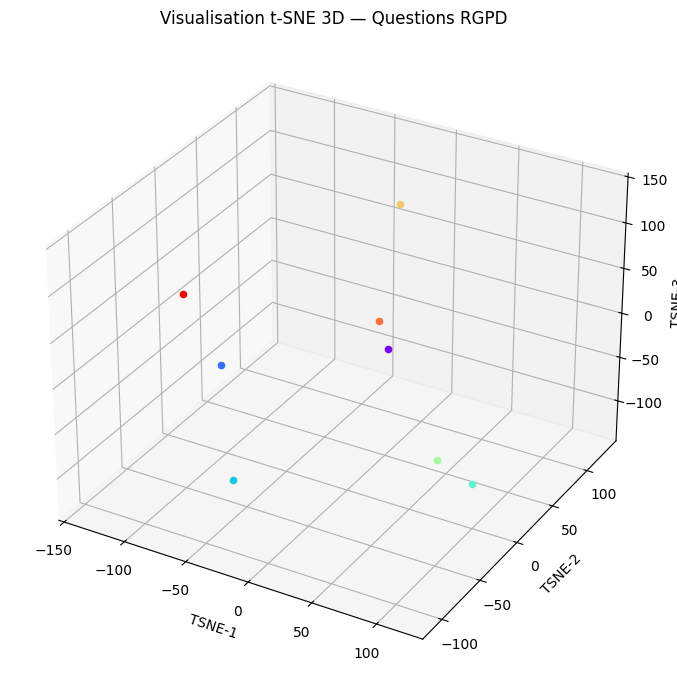

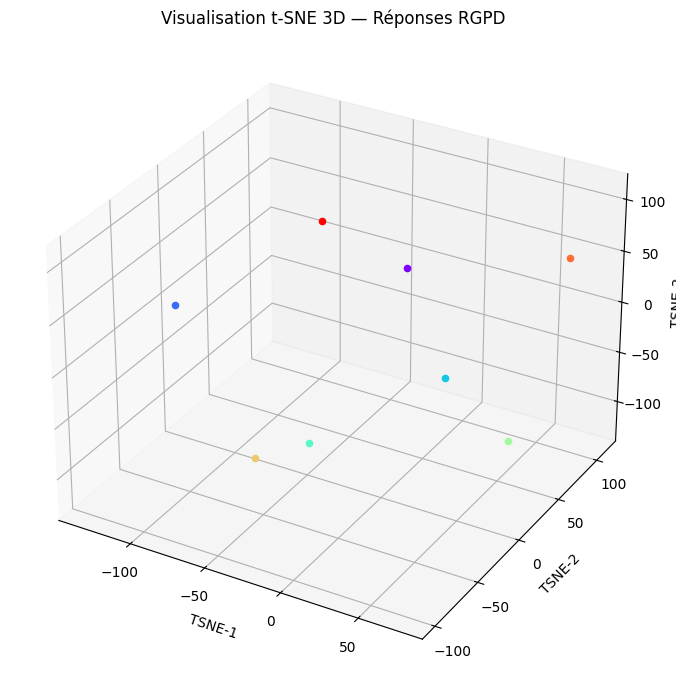

In [48]:
tsne_plot(embeddings_questions, "Questions RGPD")
tsne_plot(embeddings_reponses,  "Réponses RGPD")

## 9. Pipeline RAG — Recherche par similarité

### 9.1 Dot product (produit scalaire)

Pour une question, on calcule le produit scalaire avec tous les chunks encodés.
Les chunks avec les scores les plus élevés sont les plus pertinents.

In [49]:
def RAG_QA(question_embeddings, context_embeddings, all_chunks, n_responses=3):
    """
    Retrouve les chunks les plus pertinents par produit scalaire.

    Args:
        question_embeddings : tenseur (1, 768) de la question encodée
        context_embeddings  : tenseur (N, 768) de tous les chunks encodés
        all_chunks          : liste des textes de chunks
        n_responses         : nombre de chunks à retourner

    Returns:
        list of str : les n_responses chunks les plus pertinents
    """
    dot_product = (question_embeddings @ context_embeddings.T).reshape(-1)
    sorted_indices = torch.argsort(dot_product, descending=True).tolist()

    top_chunks = [all_chunks[i] for i in sorted_indices[:n_responses]]
    return top_chunks

### 9.2 Cosine similarity

La similarité cosinus ne tient compte que de la *direction* des vecteurs,
pas de leur magnitude — ce qui la rend plus robuste pour les textes de longueurs variables.

$$\text{cosine\_sim}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

In [50]:
def RAG_QA_cosine(question_embeddings, context_embeddings, all_chunks, n_responses=3):
    """
    Retrouve les chunks les plus pertinents par similarité cosinus.

    Args:
        question_embeddings : tenseur (1, 768)
        context_embeddings  : tenseur (N, 768)
        all_chunks          : liste des textes de chunks
        n_responses         : nombre de chunks à retourner

    Returns:
        list of str : les n_responses chunks les plus pertinents
    """
    question_norms = torch.norm(question_embeddings, dim=1, keepdim=True)       # (1, 1)
    context_norms  = torch.norm(context_embeddings,  dim=1, keepdim=True)       # (N, 1)

    dot_product       = question_embeddings @ context_embeddings.T              # (1, N)
    cosine_similarity = (dot_product / (question_norms * context_norms.T)).reshape(-1)  # (N,)

    sorted_indices = torch.argsort(cosine_similarity, descending=True).tolist()
    top_chunks = [all_chunks[i] for i in sorted_indices[:n_responses]]
    return top_chunks

## 10. Exemple d'utilisation — Question → Chunks pertinents

In [54]:
question = "qu'est ce que dit  l'article 19  sur l'obligation de notification"

# Encoder la question
q_emb = text_to_emb([question])

# --- Dot product ---
print("=== Résultats (dot product) ===")
top_dot = RAG_QA(q_emb, context_embeddings, all_chunks, n_responses=3)
for i, chunk in enumerate(top_dot, 1):
    print(f"\n[Chunk {i}]\n{chunk}")

print("\n" + "="*60)

# --- Cosine similarity ---
print("\n=== Résultats (cosine similarity) ===")
top_cos = RAG_QA_cosine(q_emb, context_embeddings, all_chunks, n_responses=3)
for i, chunk in enumerate(top_cos, 1):
    print(f"\n[Chunk {i}]\n{chunk}")

100%|██████████| 1/1 [00:00<00:00, 12.16it/s]

=== Résultats (dot product) ===

[Chunk 1]
. Lorsque la personne concernée présente sa demande par voie électronique, les informations sont fournies sous une forme électronique d'usage courant, à moins que la personne concernée ne demande qu'il en soit autrement.

[Chunk 2]
3.   Une personne concernée qui a obtenu la limitation du traitement en vertu du paragraphe 1 est informée par le responsable du traitement avant que la limitation du traitement ne soit levée.

[Chunk 3]
. Tout registre complet des condamnations pénales ne peut être tenu que sous le contrôle de l'autorité publique.


=== Résultats (cosine similarity) ===

[Chunk 1]
. Dans ce cas, les circonstances permettant de considérer qu'il est urgent d'intervenir conformément à l'article 66, paragraphe 1, sont réputées réunies et nécessitent une décision contraignante d'urgence du comité en application de l'article 66, paragraphe 2.

[Chunk 2]
. Dans ce cas, les circonstances permettant de considérer qu'il est urgent d'interven

## 11. Comparaison dot product vs cosine sur plusieurs questions

In [56]:
test_questions = [
    "qu'est ce que dit  l'article 19  sur l'obligation de notification",
    "Dans quelle chapitre on parle de Obligation de notification en ce qui concerne la rectification ou l'effacement de données à caractère personnel ou la limitation du traitement ",
    "Quelles sanctions en cas de violation ?"
]

for q in test_questions:
    q_emb = text_to_emb([q])
    print(f"\n{'='*60}")
    print(f"Question : {q}")

    cos_chunks = RAG_QA_cosine(q_emb, context_embeddings, all_chunks, n_responses=1)
    print(f"\nChunk le plus pertinent (cosine) :\n{cos_chunks[0][:300]}...")

100%|██████████| 1/1 [00:00<00:00, 16.16it/s]



Question : qu'est ce que dit  l'article 19  sur l'obligation de notification

Chunk le plus pertinent (cosine) :
. Dans ce cas, les circonstances permettant de considérer qu'il est urgent d'intervenir conformément à l'article 66, paragraphe 1, sont réputées réunies et nécessitent une décision contraignante d'urgence du comité en application de l'article 66, paragraphe 2....


100%|██████████| 1/1 [00:00<00:00, 16.39it/s]



Question : Dans quelle chapitre on parle de Obligation de notification en ce qui concerne la rectification ou l'effacement de données à caractère personnel ou la limitation du traitement 

Chunk le plus pertinent (cosine) :
Article 19
Obligation de notification en ce qui concerne la rectification ou l'effacement de données à caractère personnel ou la limitation du traitement...


100%|██████████| 1/1 [00:00<00:00, 24.77it/s]


Question : Quelles sanctions en cas de violation ?

Chunk le plus pertinent (cosine) :
. Elle ne porte pas atteinte à la validité des actes délégués déjà en vigueur....
